# Surface renewal on one day of real data — OLA almond orchard, 11 May 2023

This notebook runs both `srflux` detectors end to end on a single day from an almond
orchard eddy-covariance site, and calibrates them against the tower.

**What is in `examples/data/`**

| file | contents |
|---|---|
| `ola_2023-05-11_1hz.csv.gz` | 1 Hz **FWT** (fine-wire thermocouple, air), **IRT** (radiometer target = canopy skin), **SBT** (the radiometer's housing thermistor), 86,400 samples |
| `ola_2023-05_calibration.json` | α fitted on **1–14 May 2023 except this day**, by regime — the coefficients applied below |
| `ola_2023-05-11_flux30.csv` | 30-min **NETRAD**, **G**, **H**, **LE** from the tower (48 blocks) |

Nothing else is needed: the two temperature series are the surface-renewal input, and the
four flux terms are the reference and the energy balance.

**This day is a traditional, non-advective case with instruments in good order.** Sensible
heat is upward by day (median +105 W m⁻²) and downward at night (median −34), the Bowen ratio
is 0.32, the energy balance closes to 1.03, and all 48 blocks are complete.

What makes it a fair test is the nights. They are **coupled** (u\* ≈ 0.21 m s⁻¹) rather than
calm, so the nocturnal eddy-covariance reference is trustworthy — at other sites the days that
look "traditional" often do so because their nights are so still that the tower itself becomes
unreliable, which is not a fair comparison for surface renewal.

The instruments cooperate too: the fine wire gives a stable calibration across 3–12 May
(per-day α 0.62–0.72) and the IRT housing thermistor sits within 0.01 K of it, so all three
temperature channels can be taken at face value here.

**The calibration is not fitted here.** α comes from `ola_2023-05_calibration.json`, fitted on
1–14 May 2023 with this day excluded, and applied out-of-sample. The window stops at 14 May
deliberately: the fine wire degrades afterwards (per-day α falling to 0.04–0.50, ramp
amplitudes inflating to 1 K by 21 May), and pooling the whole month drops the air-channel
correlation from 0.85 to 0.36 through that drift alone.

**Timestamp convention: every timestamp labels the START of its period.** A row stamped
12:00 in the flux file is the average over 12:00–12:30, and the 1 Hz block grouped at 12:00
covers the same half hour. `pd.Grouper(freq="30min")` is left-labelled and left-closed, which
is why the two join directly. This was verified rather than assumed: with the mean diurnal
cycle removed, the fine wire (IRT logger) correlates with the air temperature (EC logger)
best at zero shift, and the correlation drops on either side — a half-hour misalignment
would have peaked at ±1 block.

The `NETRAD` and `G` columns are QC'd, partly gap-filled products rather than raw sensor
readings (net radiation reconstructed against clear-sky models; soil heat flux with per-plate
flagging and 2–6 cm storage), so treat them as the pipeline's best estimate of the energy
balance rather than as measurements.

The two ramp scalars are a deliberate contrast. The fine wire sits in the air and sees the sharp
microfronts directly; IRT looks at the canopy skin, whose ramps are smoother, smaller and
harder to detect — which is exactly where surface renewal is most useful, because a
radiometer is cheap and needs no sonic.

The third channel, **SBT**, is not a ramp scalar at all. It is the thermistor inside the
radiometer housing, which equilibrates with the *air* rather than the canopy, so the
difference `dT = IRT − SBT ≈ Ts − Ta` is available from the single instrument. Section 6
uses it for the flux direction and the stability class, which is otherwise the one thing
surface renewal cannot get from a radiometer alone.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from srflux import (HaarDetector, VanAttaDetector, prepare_block, ramp_flux,
                    calibrate_alpha, fit_and_score, sensible_heat,
                    latent_heat_residual, daily_et, sign_from_skewness,
                    sign_from_gradient, fit_gradient_offset, stability_from_gradient,
                    surface_air_difference)
from srflux.preprocess import increment_skewness

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

FS = 1.0            # Hz, the raw sampling rate
BLOCK_S = 1800.0    # 30-min averaging period
Z_AIR = 10.5        # m, sonic/fine-wire measurement height
Z_CANOPY = 5.5      # m, canopy height -- the right length scale for a SKIN temperature

hi = pd.read_csv("data/ola_2023-05-11_1hz.csv.gz", parse_dates=["TIMESTAMP"])
fx = pd.read_csv("data/ola_2023-05-11_flux30.csv", parse_dates=["TIMESTAMP"])
hi = hi.set_index("TIMESTAMP")
fx = fx.set_index("TIMESTAMP")

print(hi.describe().round(2).to_string())
fx.head()

            FWT       IRT       SBT
count  86400.00  86400.00  86400.00
mean      16.50     15.44     16.72
std        5.13      5.60      5.25
min        8.23      7.03      8.35
25%       11.28     10.06     11.39
50%       16.04     14.23     16.44
75%       21.59     21.58     22.05
max       24.83     23.62     24.15


,NETRAD,G,H,LE
TIMESTAMP,,,,
2023-05-11 00:00:00,-94.90,-34.47,-30.43,14.31
2023-05-11 00:30:00,-94.47,-34.88,-53.25,27.71
2023-05-11 01:00:00,-95.92,-35.34,-50.61,22.51
2023-05-11 01:30:00,-95.73,-35.60,-93.83,41.24
2023-05-11 02:00:00,-94.99,-35.73,-65.07,28.00


## 1. The day at a glance

Top: the two raw 1 Hz series. The fine wire tracks air temperature and is visibly noisier;
the canopy skin runs *below* air through the middle of the day, which is what a transpiring
orchard should do — evaporative cooling holds the leaves below the air around them.

Bottom: the surface energy balance. This is an irrigated orchard in June, so most of the
available energy goes into LE, and H is the smaller term. That matters later: an error in
the surface-renewal H is diluted when ET is computed as a residual.

daytime Bowen ratio  H/LE = 0.32
energy-balance closure (H+LE)/(Rn-G) = 1.03


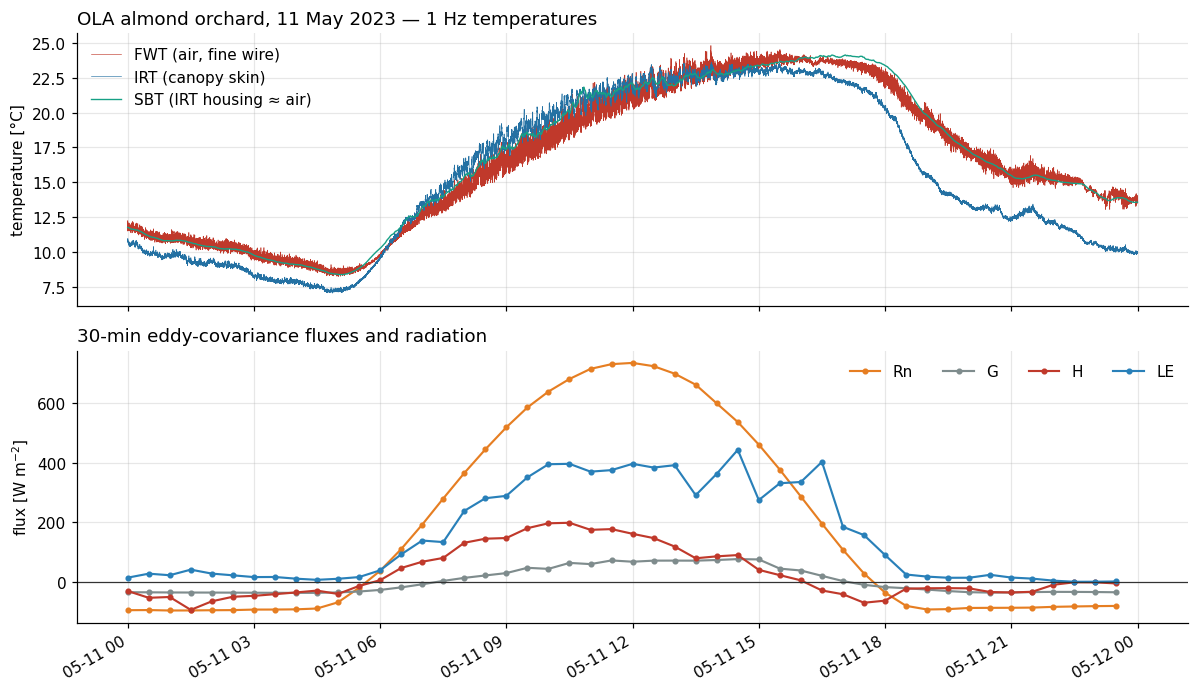

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                               gridspec_kw=dict(height_ratios=[1, 1]))

ax1.plot(hi.index, hi.FWT, lw=0.4, color="#c0392b", label="FWT (air, fine wire)")
ax1.plot(hi.index, hi.IRT, lw=0.4, color="#2471a3", label="IRT (canopy skin)")
ax1.plot(hi.index, hi.SBT, lw=0.9, color="#16a085", label="SBT (IRT housing ≈ air)")
ax1.set_ylabel("temperature [°C]")
ax1.legend(loc="upper left", frameon=False)
ax1.set_title("OLA almond orchard, 11 May 2023 — 1 Hz temperatures", loc="left")

for col, clr, lab in [("NETRAD", "#e67e22", "Rn"), ("G", "#7f8c8d", "G"),
                      ("H", "#c0392b", "H"), ("LE", "#2980b9", "LE")]:
    ax2.plot(fx.index, fx[col], "-o", ms=3, lw=1.4, color=clr, label=lab)
ax2.axhline(0, color="#333", lw=0.8)
ax2.set_ylabel("flux [W m$^{-2}$]")
ax2.legend(ncol=4, frameon=False)
ax2.set_title("30-min eddy-covariance fluxes and radiation", loc="left")
fig.autofmt_xdate()
plt.tight_layout()

closure = (fx.H + fx.LE).sum() / (fx.NETRAD - fx.G).sum()
print(f"daytime Bowen ratio  H/LE = {fx.H[fx.NETRAD > 50].sum() / fx.LE[fx.NETRAD > 50].sum():.2f}")
print(f"energy-balance closure (H+LE)/(Rn-G) = {closure:.2f}")

## 2. What a ramp actually looks like

One 30-min block at midday, for both scalars. The top panels show the raw series with its
300 s moving mean; the bottom panels show the detrended signal and the Haar coefficients,
with the detected microfronts marked.

Detection runs on the whole 30-min block; the plot shows the first few minutes so the
individual ramps stay legible. Note the difference in vertical scale — the air ramps are
several times larger than the skin ramps — and look at the asymmetry of each ramp, which
is what section 6 turns out to depend on.

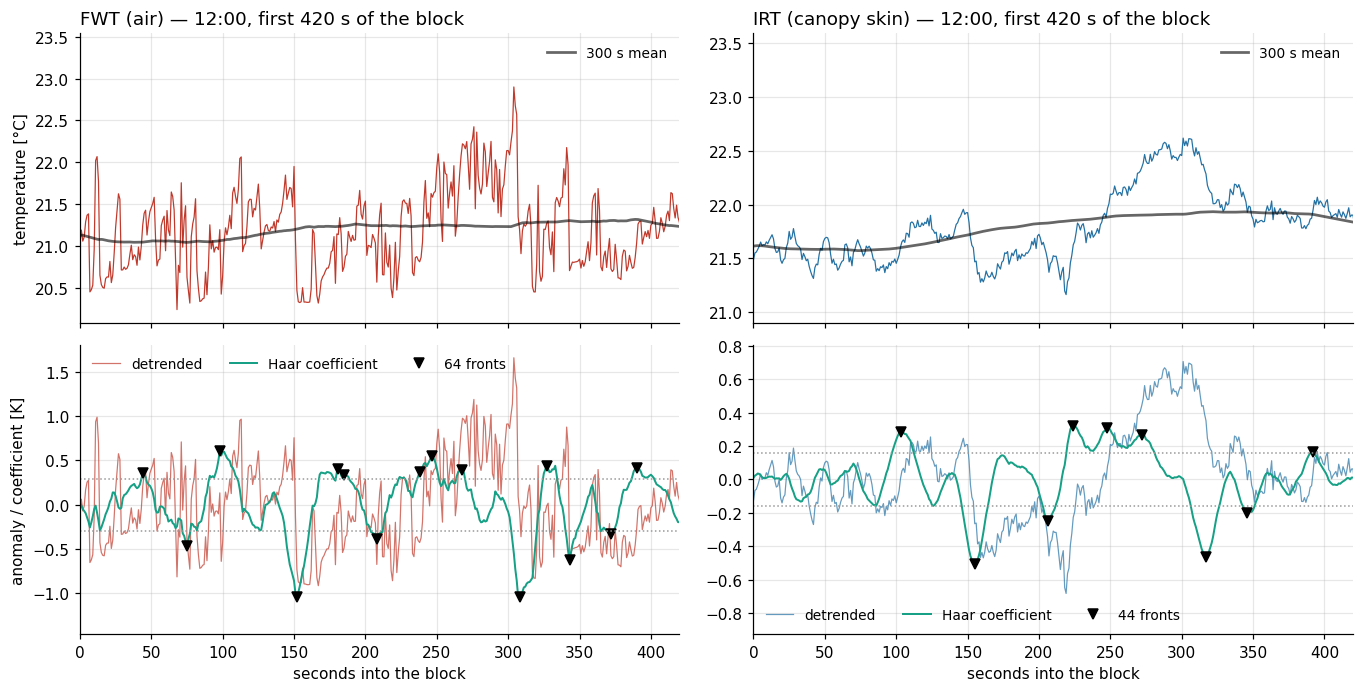

In [3]:
from srflux.preprocess import moving_average

t0 = pd.Timestamp("2023-05-11 12:00:00")
ZOOM_S = 420          # plot this many seconds so individual ramps stay legible
seg = hi.loc[t0:t0 + pd.Timedelta(seconds=BLOCK_S - 1)]
det = HaarDetector(fs=FS)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 6.4), sharex=True)
for j, (col, clr, lab) in enumerate([("FWT", "#c0392b", "FWT (air)"),
                                     ("IRT", "#2471a3", "IRT (canopy skin)")]):
    v = prepare_block(seg[col].to_numpy(), fs=FS).values
    t = np.arange(len(v))
    coef = det.coefficients(v)
    res = det.detect(v)
    idx = res.extra["front_index"]

    axes[0, j].plot(t, v, lw=0.8, color=clr)
    axes[0, j].plot(t, moving_average(v, 300, FS), lw=1.8, color="k", alpha=0.6,
                    label="300 s mean")
    axes[0, j].set_title(f"{lab} — {t0:%H:%M}, first {ZOOM_S} s of the block", loc="left")
    axes[0, j].legend(frameon=False, fontsize=9)

    axes[1, j].plot(t, v - moving_average(v, 300, FS), lw=0.8, color=clr, alpha=0.7,
                    label="detrended")
    axes[1, j].plot(t, coef, lw=1.3, color="#16a085", label="Haar coefficient")
    axes[1, j].plot(idx, coef[idx], "v", ms=6, color="#000000",
                    label=f"{res.count} fronts")
    axes[1, j].axhline(res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].axhline(-res.extra["threshold"], color="#999", ls=":", lw=1)
    axes[1, j].set_xlabel("seconds into the block")
    axes[1, j].set_xlim(0, ZOOM_S)          # detection uses the whole block; we plot a window
    axes[1, j].legend(frameon=False, fontsize=9, ncol=3)

axes[0, 0].set_ylabel("temperature [°C]")
axes[1, 0].set_ylabel("anomaly / coefficient [K]")
plt.tight_layout()

## 3. Run both detectors on every block

`HaarDetector` (SR-WL) counts fronts and reports their median amplitude; `VanAttaDetector`
(SR-VA) solves the structure-function cubic and reports an amplitude and a ramp period.

Each is turned into an uncalibrated flux with the appropriate length scale — the
measurement height for the air series, the canopy height for the skin series, since the
renewed volume against a canopy skin temperature is the canopy layer.

In [4]:
# The applied SR-VA configuration MUST match the one the coefficients were fitted with,
# so it is read from the calibration file rather than hard-coded here.
import json as _json
_cal_head = _json.load(open("data/ola_2023-05_calibration.json"))
VA_LAG, VA_MODE = _cal_head["va_lag_s"], _cal_head["va_period_mode"]

wl = HaarDetector(fs=FS)
va = VanAttaDetector(fs=FS, lag=VA_LAG, period_mode=VA_MODE)   # calibrated config
va_classical = VanAttaDetector(fs=FS, lag="chen")              # for the section-6 comparison
print(f"SR-VA applied as calibrated: lag {VA_LAG} s, period_mode '{VA_MODE}'")
AIR = "FWT"           # this site has one fine wire, and it is sound in this window
Z = {"FWT": Z_AIR, "IRT": Z_CANOPY}

rows = []
for t, g in hi.groupby(pd.Grouper(freq="30min")):
    row = {"TIMESTAMP": t}
    for col in (AIR, "IRT"):
        qc = prepare_block(g[col].to_numpy(), fs=FS)
        if not qc.ok:
            continue
        rw, rv = wl.detect(qc.values), va.detect(qc.values)
        rc = va_classical.detect(qc.values)
        row[f"{col}_sign"] = sign_from_skewness(qc.values, fs=FS)
        row[f"{col}_skew"] = increment_skewness(qc.values, fs=FS)
        if rw.valid:
            row[f"WL_{col}_N"] = rw.count
            row[f"WL_{col}_A"] = rw.amplitude
            row[f"WL_{col}_F"] = ramp_flux(rw.amplitude, count=rw.count, z=Z[col],
                                           block_s=BLOCK_S)
        if rv.valid:
            # period_mode="unit" -> period is 1 by definition, so F = rho cp z A,
            # exactly the quantity the published coefficients were fitted against
            row[f"VA_{col}_A"] = rv.amplitude
            row[f"VA_{col}_lag"] = rv.extra["lag_s"]
            row[f"VA_{col}_F"] = ramp_flux(rv.amplitude, period=rv.period, z=Z[col])
        if rc.valid:
            row[f"VAc_{col}_A"] = rc.amplitude
            row[f"VAc_{col}_tau"] = rc.period
            row[f"VAc_{col}_lag"] = rc.extra["lag_s"]
            row[f"VAc_{col}_F"] = ramp_flux(rc.amplitude, period=rc.period, z=Z[col])
    rows.append(row)

sr = pd.DataFrame(rows).set_index("TIMESTAMP")
d = fx.join(sr)
d["daytime"] = d.NETRAD > 50
day_all = d[d.daytime]

print("median ramp statistics over the day")
print(pd.DataFrame({
    "WL count": [d[f"WL_{AIR}_N"].median(), d.WL_IRT_N.median()],
    "WL amplitude [K]": [d[f"WL_{AIR}_A"].median(), d.WL_IRT_A.median()],
    "VA amplitude [K]": [d[f"VAc_{AIR}_A"].median(), d.VAc_IRT_A.median()],
    "VA period [s]": [d[f"VAc_{AIR}_tau"].median(), d.VAc_IRT_tau.median()],
    "VA Chen lag [s]": [d[f"VAc_{AIR}_lag"].median(), d.VAc_IRT_lag.median()],
}, index=["FWT (air)", "IRT (skin)"]).round(2).to_string())

SR-VA applied as calibrated: lag chen s, period_mode 'unit'


median ramp statistics over the day
            WL count  WL amplitude [K]  VA amplitude [K]  VA period [s]  VA Chen lag [s]
FWT (air)       68.5              0.25              0.41          12.48              2.0
IRT (skin)      56.5              0.10              0.22         106.85             59.5


The Chen lag is the number to look at. It adapts to the scalar: a couple of seconds on the
fine wire, tens of seconds on the skin temperature. A fixed 1 s lag — the textbook choice
for a sonic — would have collapsed on the IRT series.

## 4. Uncalibrated flux against the tower

Before any calibration, the shape is already right: the surface-renewal quantity rises and
falls with H through the day. Calibration is a single multiplicative constant.

The three series live on very different scales — the skin-temperature flux is smaller than
the air one by roughly an order of magnitude, because the skin ramps are smaller (median
amplitude 0.10 K against 0.37 K) and the canopy height is a shorter length scale than the
measurement height. Plotting them on a
shared axis would flatten the skin trace into a line, so each gets its own axis below.

full ranges over the day [W m-2] — note how far apart the scales are, and that
SR-VA's skin flux has a nocturnal block where the fitted tau collapses:
               WL           VA
H_EC    -94 … 199    -94 … 199
F air    28 … 289  170 … 15120
F skin     9 … 80   295 … 5426


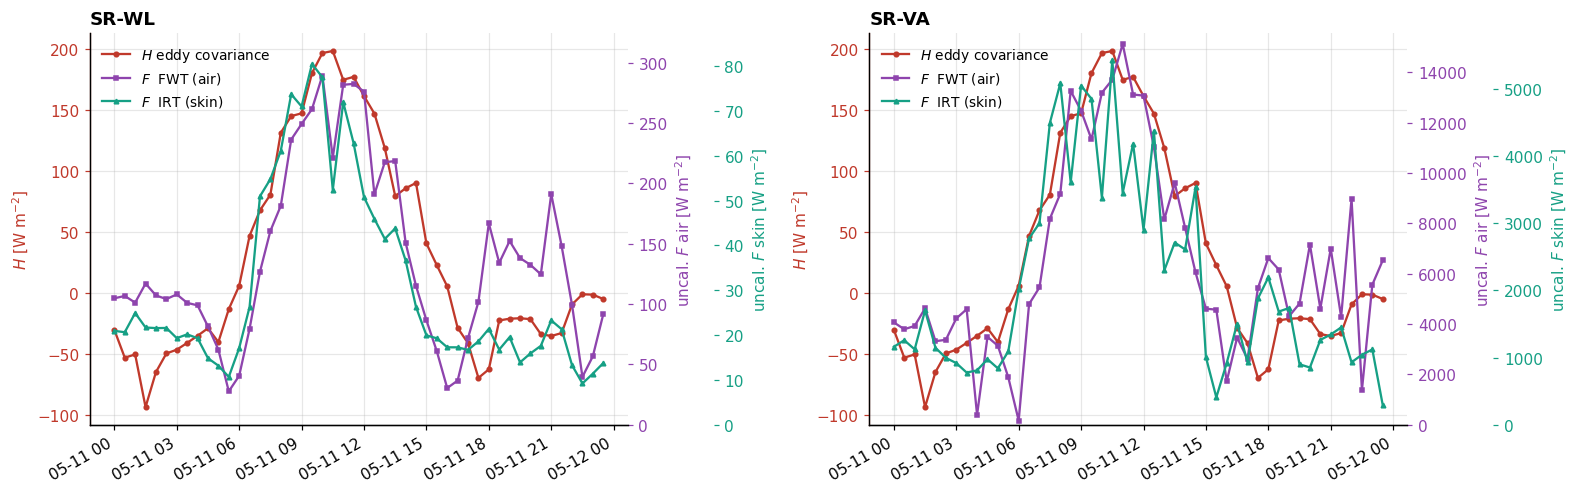

In [5]:
# Three quantities, three scales: H is O(100) W m-2, the air ramp flux O(10-300), and the
# skin ramp flux an order of magnitude smaller again. Each gets its own axis, and the axis
# is coloured to match its series so the reader is never guessing which scale to read.
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6), sharex=True)
C_H, C_AIR, C_SKIN = "#c0392b", "#8e44ad", "#16a085"

for ax, meth in zip(axes, ["WL", "VA"]):
    ax_air = ax.twinx()
    ax_skin = ax.twinx()
    ax_skin.spines["right"].set_position(("axes", 1.16))   # push the third axis outward

    l0, = ax.plot(d.index, d.H, "-o", ms=3, color=C_H, label="$H$ eddy covariance")
    l1, = ax_air.plot(d.index, d[f"{meth}_{AIR}_F"], "-s", ms=3, color=C_AIR,
                      label="$F$  FWT (air)")
    l2, = ax_skin.plot(d.index, d[f"{meth}_IRT_F"], "-^", ms=3, color=C_SKIN,
                       label="$F$  IRT (skin)")

    # robust limits: a single block whose tau collapses can send A/tau to thousands of
    # W m-2 and squash everything else flat. Clip the view, and say how much is off-scale.
    for a, col in ((ax_air, f"{meth}_{AIR}_F"), (ax_skin, f"{meth}_IRT_F")):
        v = d[col].to_numpy(float)
        hi_lim = np.nanpercentile(v, 97) * 1.15
        a.set_ylim(min(0, np.nanmin(v)), hi_lim)
        n_off = int(np.nansum(v > hi_lim))
        if n_off:
            a.annotate(f"{n_off} block off-scale (max {np.nanmax(v):.0f})",
                       xy=(0.99, 0.98), xycoords="axes fraction", ha="right", va="top",
                       fontsize=8, color="#555555")

    ax.set_ylabel("$H$ [W m$^{-2}$]", color=C_H)
    ax_air.set_ylabel("uncal. $F$ air [W m$^{-2}$]", color=C_AIR)
    ax_skin.set_ylabel("uncal. $F$ skin [W m$^{-2}$]", color=C_SKIN)
    for a, c in ((ax, C_H), (ax_air, C_AIR), (ax_skin, C_SKIN)):
        a.tick_params(axis="y", colors=c)
        a.spines["right"].set_color(c)
    ax.spines["left"].set_color(C_H)
    ax_air.grid(False)
    ax_skin.grid(False)
    ax.set_title(f"SR-{meth}", loc="left", fontweight="bold")
    ax.legend(handles=[l0, l1, l2], frameon=False, fontsize=9, loc="upper left")

fig.autofmt_xdate()
plt.tight_layout()

print("full ranges over the day [W m-2] — note how far apart the scales are, and that")
print("SR-VA's skin flux has a nocturnal block where the fitted tau collapses:")
print(pd.DataFrame({m: {"H_EC": f"{d.H.min():.0f} … {d.H.max():.0f}",
                        "F air":  f"{d[f'{m}_{AIR}_F'].min():.0f} … {d[f'{m}_{AIR}_F'].max():.0f}",
                        "F skin": f"{d[f'{m}_IRT_F'].min():.0f} … {d[f'{m}_IRT_F'].max():.0f}"}
                    for m in ("WL", "VA")}).to_string())

## 5. Apply the month calibration (out-of-sample)

α is loaded, not fitted. `ola_2023-05_calibration.json` was produced from **all of May 2026
except this day** by `data/make_wes_calibration.py`, which publishes only the coefficients —
the month of raw data stays where it is.

Two regimes are calibrated separately, because a coefficient fitted on daytime convection
over-estimates the weak nocturnal flux:

| regime | definition | sign |
|---|---|---|
| `unstable_day` | Rn > 50 W m⁻², H > 0 | +1 |
| `stable_night` | Rn < −20 W m⁻², H < 0 | −1 |

At **application** time the regime is chosen from net radiation alone — never from H, which
is the quantity being predicted — so the procedure needs no eddy-covariance input beyond the
calibration that was done once, elsewhere.

In [6]:
import json

combos = [("WL", AIR), ("WL", "IRT"), ("VA", AIR), ("VA", "IRT")]

with open("data/ola_2023-05_calibration.json") as fh:
    CAL = json.load(fh)
print(f"fitted on {CAL['fit_period']}, excluding {CAL['excluded_day']}")
print(f"QC: {CAL['qc']}\n")
coef = pd.DataFrame({r: {k: v["alpha"] for k, v in c.items()}
                     for r, c in CAL["coefficients"].items()})
skill = pd.DataFrame({r: {k: v["r"] for k, v in c.items()}
                      for r, c in CAL["coefficients"].items()})
print("alpha by regime:"); print(coef.round(3).to_string())
print("\nmonth-fit r by regime:"); print(skill.round(2).to_string())

fitted on 2023-05-01 to 2023-05-14, excluding 2023-05-11
QC: ramp amplitudes above 3.0 K rejected; window stops at 14 May because the fine wire degrades afterwards (per-day alpha 0.62-0.72 before, 0.04-0.50 after)

alpha by regime:
        unstable_day  stable_night
WL_FWT         0.496         0.304
WL_IRT         2.342         2.569
VA_FWT         0.000         0.001
VA_IRT         0.015         0.032

month-fit r by regime:
        unstable_day  stable_night
WL_FWT          0.56          0.40
WL_IRT          0.72          0.90
VA_FWT         -0.06          0.04
VA_IRT          0.38          0.47


Two things stand out before any of it is applied.

**The skin channel calibrates better than the air channel at this site**, and by a wide
margin at night: r 0.72 by day and **0.90** at night against 0.56 and 0.40 for the fine wire.
Nocturnal skill is the surprise — surface renewal is built on convective structures, yet the
radiometer tracks the weak stable-regime flux more tightly than the daytime one, with an RMSE
of 15 W m⁻².

**The night coefficient is slightly LARGER than the daytime one** on the skin channel (2.57
against 2.34), where other sites in this record give a night coefficient half the day's or
smaller. The regime split is worth carrying regardless — but its size is a property of the
site and season, not a constant of the method.

In [7]:
def regime_of(rn):
    # regime from net radiation alone -- no eddy-covariance input at application time
    if rn > 50:
        return "unstable_day"
    if rn < -20:
        return "stable_night"
    return "unstable_day" if rn > 0 else "stable_night"      # transition blocks

REGIME_SIGN = {"unstable_day": +1.0, "stable_night": -1.0}

d["regime"] = [regime_of(v) for v in d.NETRAD]
for meth, col in combos:
    key = f"{meth}_{col}"
    alpha = np.array([CAL["coefficients"][r].get(key, {}).get("alpha", np.nan)
                      for r in d.regime])
    sign = np.array([REGIME_SIGN[r] for r in d.regime])
    d[f"H_{key}"] = sign * alpha * d[f"{key}_F"]

print(d.groupby("regime").size().rename("blocks").to_frame().T.to_string())
d[["NETRAD", "H", "regime"] + [f"H_{m}_{c}" for m, c in combos]].head(4).round(1)

regime  stable_night  unstable_day
blocks            24            24


,NETRAD,H,regime,H_WL_FWT,H_WL_IRT,H_VA_FWT,H_VA_IRT
TIMESTAMP,,,,,,,
2023-05-11 00:00:00,-94.9,-30.4,stable_night,-31.9,-53.8,-3.3,-37.0
2023-05-11 00:30:00,-94.5,-53.2,stable_night,-32.5,-53.1,-3.0,-40.2
2023-05-11 01:00:00,-95.9,-50.6,stable_night,-30.8,-64.0,-3.1,-35.8
2023-05-11 01:30:00,-95.7,-93.8,stable_night,-35.6,-55.8,-3.7,-54.3


,method,scalar,r,rmse,mbe,n
0,SR-WL,FWT,0.92,34.74,-3.50,48
1,SR-WL,IRT,0.92,33.73,0.54,48
2,SR-VA,FWT,0.72,87.59,-29.44,48
3,SR-VA,IRT,0.87,55.50,-23.19,48


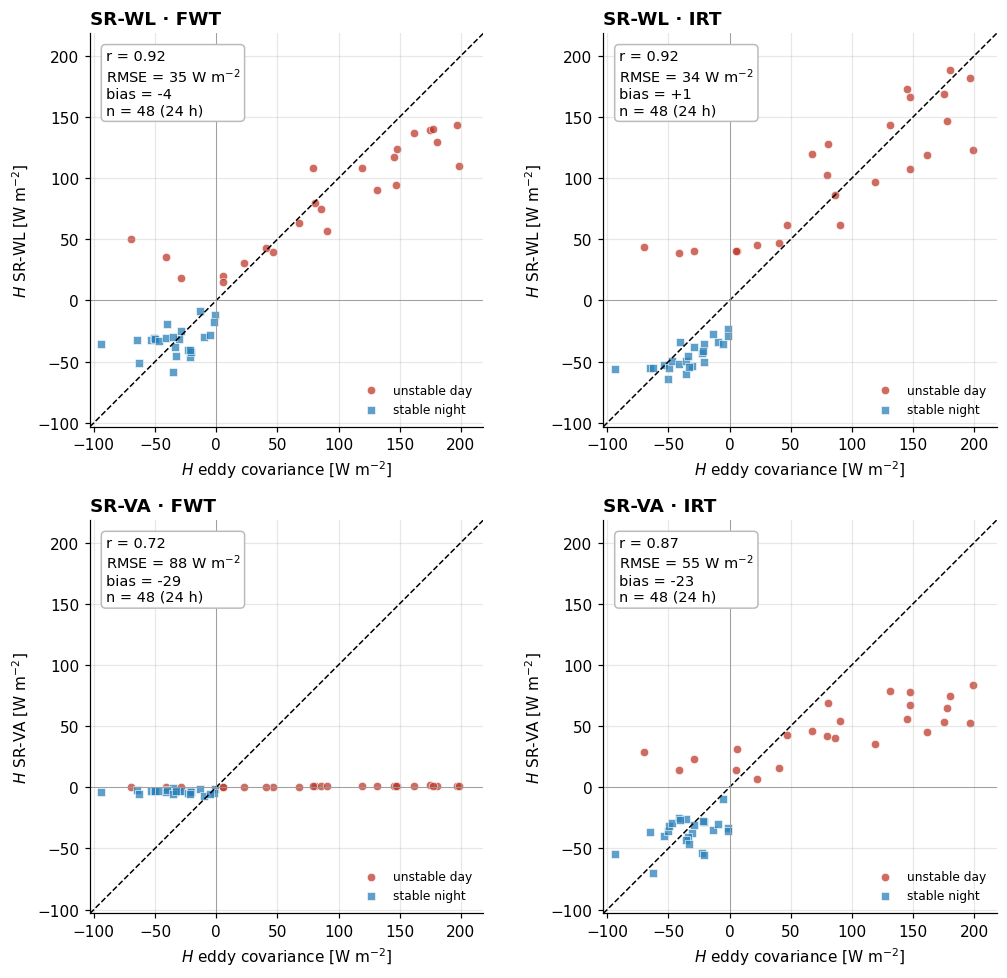

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9.6, 9.0))
scores = {}
for ax, (meth, col) in zip(axes.ravel(), combos):
    v = d[[f"H_{meth}_{col}", "H", "regime"]].dropna()
    est, obs = v[f"H_{meth}_{col}"].to_numpy(), v.H.to_numpy()
    err = est - obs
    scores[(meth, col)] = dict(r=float(np.corrcoef(est, obs)[0, 1]),
                               rmse=float(np.sqrt(np.mean(err ** 2))),
                               mbe=float(np.mean(err)), n=len(v))
    for reg, mk, cl in [("unstable_day", "o", "#c0392b"), ("stable_night", "s", "#2980b9")]:
        m = v.regime == reg
        ax.scatter(obs[m], est[m], s=30, marker=mk, color=cl, alpha=0.75,
                   edgecolors="white", lw=0.5, label=reg.replace("_", " "))
    lim = [min(obs.min(), est.min()) * 1.1, max(obs.max(), est.max()) * 1.1]
    ax.plot(lim, lim, "k--", lw=1)
    ax.axhline(0, color="#999", lw=0.6); ax.axvline(0, color="#999", lw=0.6)
    ax.set(xlim=lim, ylim=lim, aspect="equal")
    ax.set_xlabel("$H$ eddy covariance [W m$^{-2}$]")
    ax.set_ylabel(f"$H$ SR-{meth} [W m$^{{-2}}$]")
    ax.set_title(f"SR-{meth} · {col}", loc="left", fontweight="bold")
    sc = scores[(meth, col)]
    ax.text(0.04, 0.96, f"r = {sc['r']:.2f}\nRMSE = {sc['rmse']:.0f} W m$^{{-2}}$\n"
                        f"bias = {sc['mbe']:+.0f}\nn = {sc['n']} (24 h)",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round", fc="white", ec="#bbb"))
    ax.legend(fontsize=8, loc="lower right", frameon=False)
plt.tight_layout()

pd.DataFrame([{"method": f"SR-{m}", "scalar": c, **scores[(m, c)]} for m, c in combos]).round(2)

These are predictions, not fits: every α came from other days. The scatter now covers the
full 24 hours, and the nocturnal blocks (blue squares) sit in the lower-left quadrant, where
both the tower and surface renewal report a downward flux.

Read RMSE rather than r here. Spanning day and night puts the points into two well-separated
clouds, and a correlation computed across both is flattered by that separation — it says
partly that the method knows night from day. RMSE and bias carry the information about the
estimate itself.

### What did the out-of-sample calibration cost?

Fitting α on this day instead — the in-sample version of the same plot — gives the
comparison below. The gap is the price of not having the day in the calibration, and it is
the quantity that matters when the method is deployed at a site with no tower.

In [9]:
rows = []
for meth, col in combos:
    v = d[[f"{meth}_{col}_F", "H", "regime"]].dropna()
    for reg in ("unstable_day", "stable_night"):
        sub = v[v.regime == reg]
        if len(sub) < 6:
            continue
        F, H = sub[f"{meth}_{col}_F"].to_numpy(), sub.H.abs().to_numpy()
        a_day = calibrate_alpha(F, H)                      # this day only (in-sample)
        a_mon = CAL["coefficients"][reg].get(f"{meth}_{col}", {}).get("alpha", np.nan)
        sgn = REGIME_SIGN[reg]
        rmse = lambda a: float(np.sqrt(np.mean((sgn * a * F - sub.H.to_numpy()) ** 2)))
        rows.append({"method": f"SR-{meth}", "scalar": col, "regime": reg, "n": len(sub),
                     "alpha_month": a_mon, "alpha_this_day": round(a_day, 3),
                     "ratio": round(a_mon / a_day, 2) if a_day else np.nan,
                     "RMSE_month": round(rmse(a_mon), 1),
                     "RMSE_this_day": round(rmse(a_day), 1)})
pd.DataFrame(rows)

,method,scalar,regime,n,alpha_month,alpha_this_day,ratio,RMSE_month,RMSE_this_day
0,SR-WL,FWT,unstable_day,24,0.4961,0.628,0.79,44.5,40.3
1,SR-WL,FWT,stable_night,24,0.3044,0.302,1.01,20.7,20.7
2,SR-WL,IRT,unstable_day,24,2.3416,2.349,1.00,43.7,43.7
3,SR-WL,IRT,stable_night,24,2.5686,2.018,1.27,19.2,16.4
4,SR-VA,FWT,unstable_day,24,0.0001,0.013,0.01,118.1,40.4
5,SR-VA,FWT,stable_night,24,0.0008,0.006,0.13,37.5,26.5
6,SR-VA,IRT,unstable_day,24,0.0154,0.034,0.46,75.9,51.6
7,SR-VA,IRT,stable_night,24,0.0319,0.029,1.10,20.0,19.7


## 6. SR-VA on the skin temperature: does the fitted period earn its place?

SR-VA divides the amplitude by a fitted ramp period, and on a 1 Hz skin temperature that
period is the least trustworthy thing in the calculation — here it ranges from about 15 s to
over 300 s across the day's blocks. `period_mode="unit"` sets tau = 1 and uses the
**amplitude alone**, `F = rho cp z A`, folding the duration into the calibration coefficient.

Whether that helps depends on the lag, because the Chen criterion optimises `|S3(r)|/r` —
the right target when you want a period, the wrong one once you have decided to discard it.
The sweep below varies the lag with the period dropped.

IRT: classical A/τ (Chen)      r = +0.16
IRT: amplitude only, Chen lag  r = +0.75
IRT: amplitude only, fixed 2 s      r = +0.84   <-- best


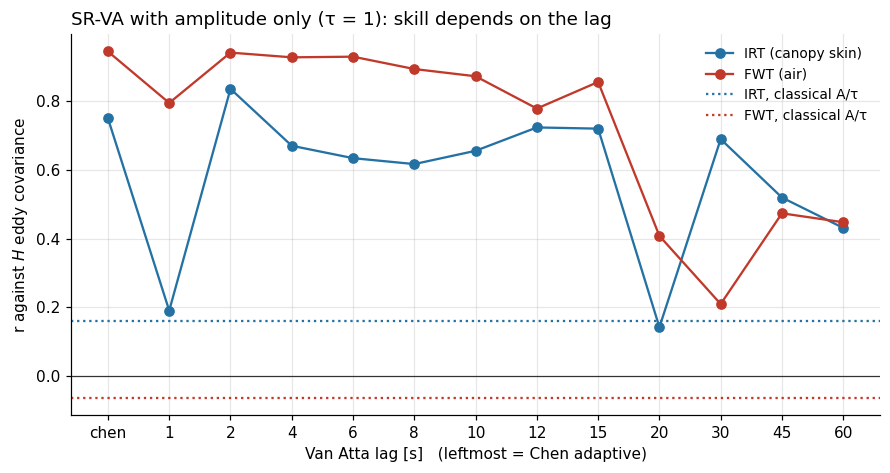

In [10]:
# the sweep compares lags within this day; r is scale-invariant so no calibration enters
cal = d[(d.regime == "unstable_day") & (d.H > 0)].dropna(subset=[f"VAc_{AIR}_F", "VAc_IRT_F"])
ref_r = {c: float(np.corrcoef(cal[f"VAc_{c}_F"], cal.H)[0, 1]) for c in (AIR, "IRT")}

lags = ["chen", 1, 2, 4, 6, 8, 10, 12, 15, 20, 30, 45, 60]
blocks = {t: {c: prepare_block(g[c].to_numpy(), fs=FS) for c in (AIR, "IRT")}
          for t, g in hi.groupby(pd.Grouper(freq="30min"))}

sweep = []
for lag in lags:
    row = {"lag": lag}
    for col in (AIR, "IRT"):
        det = VanAttaDetector(fs=FS, lag=lag, period_mode="unit")
        A = np.array([det.detect(blocks[t][col].values).amplitude for t in cal.index])
        F = ramp_flux(A, period=1.0, z=Z[col])          # tau = 1: amplitude only
        row[f"r_{col}"] = fit_and_score(F, cal.H.to_numpy()).r
    sweep.append(row)
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
x = np.arange(len(lags))
ax.plot(x, sweep.r_IRT, "-o", color="#2471a3", label="IRT (canopy skin)")
ax.plot(x, sweep.r_FWT, "-o", color="#c0392b", label="FWT (air)")
ax.axhline(ref_r["IRT"], color="#2471a3", ls=":", lw=1.5, label="IRT, classical A/τ")
ax.axhline(ref_r[AIR], color="#c0392b", ls=":", lw=1.5, label="FWT, classical A/τ")
ax.axhline(0, color="#333", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([str(v) for v in lags])
ax.set_xlabel("Van Atta lag [s]   (leftmost = Chen adaptive)")
ax.set_ylabel("r against $H$ eddy covariance")
ax.set_title("SR-VA with amplitude only (τ = 1): skill depends on the lag", loc="left")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

best = sweep.loc[sweep.r_IRT.idxmax()]
print(f"IRT: classical A/τ (Chen)      r = {ref_r['IRT']:+.2f}")
print(f"IRT: amplitude only, Chen lag  r = {sweep.r_IRT.iloc[0]:+.2f}")
lag_lab = "Chen adaptive" if best.lag == "chen" else f"fixed {best.lag} s"
print(f"IRT: amplitude only, {lag_lab:<14} r = {best.r_IRT:+.2f}   <-- best")

**Dropping the period is worth a great deal here**, and the lag choice is worth more still.
On this day the classical `A/τ` manages r ≈ 0.16 on the skin channel; the amplitude alone at
the same Chen lag reaches 0.75, and a fixed 2 s lag 0.84. Nothing is lost by discarding a
quantity a 1 Hz record cannot estimate reliably.

**But do not read the peak of this curve as the lag to use.** Swept over the 13-day
calibration window instead of this one day, the ranking changes: the Chen adaptive lag wins
(skin r 0.38 by day, 0.47 at night) and a fixed 2 s falls to 0.19. The published coefficients
therefore use the Chen lag, chosen on the calibration set — a single day has far too few
blocks to select a hyperparameter, and the day's own optimum would not have generalised.

On the fine wire SR-VA does not work at this site at any lag (|r| < 0.1 across the window),
which is why its panels above are flat. The Haar detector has no such trouble with the same
signal.

## 7. Flux direction and stability from the radiometer alone (Ta from the sensor body)

The ramp amplitude says how big the exchange is, not which way it goes. Three candidates,
none of which needs a sonic:

1. `sign_from_skewness` on the **air** ramp — a warm ramp rises gradually and collapses
   sharply, so the increment skewness is negative;
2. the same on the **skin** ramp;
3. `sign_from_gradient` — the **surface-air temperature difference** `dT = IRT − SBT`, taken
   from the two channels of the one radiometer. The housing thermistor tracks air rather
   than canopy, so dT is a direct thermodynamic statement: surface warmer than air means
   heat goes up. No time-domain statistics at all.

The first thing to check is whether the housing really behaves like an air sensor here.

In [11]:
b = hi.resample("30min").mean()
d = d.join(b[["SBT"]].rename(columns={"SBT": "SBT_mean"}))
d = d.join(hi.IRT.resample("30min").mean().rename("IRT_mean"))
d["dT"] = surface_air_difference(d.IRT_mean, d.SBT_mean)
day_all = d[d.daytime]

print(f"SBT vs FWT over the day:  r = {b.SBT.corr(b[AIR]):.3f}, "
      f"mean SBT − FWT = {(b.SBT - b[AIR]).mean():+.2f} K")
print(f"midday (11–15 h) FWT {b[AIR].between_time('11:00','15:00').mean():.1f} °C, "
      f"SBT {b.SBT.between_time('11:00','15:00').mean():.1f} °C, "
      f"IRT {b.IRT.between_time('11:00','15:00').mean():.1f} °C")

SBT vs FWT over the day:  r = 0.996, mean SBT − FWT = +0.22 K
midday (11–15 h) FWT 22.4 °C, SBT 22.5 °C, IRT 22.4 °C


The housing now tracks the fine wire closely in both shape and level — a housing thermistor
behaving as an air proxy should. Whether that makes it a good flux-direction indicator is a
separate question, settled empirically below.

In [12]:
sources = {
    "skewness · FWT (air ramp)":  day_all[f"{AIR}_sign"],
    "skewness · IRT (skin ramp)": day_all.IRT_sign,
    "gradient · IRT − SBT":       sign_from_gradient(day_all.IRT_mean, day_all.SBT_mean),
    "gradient · IRT − FWT":       sign_from_gradient(day_all.IRT_mean,
                                                     b[AIR].reindex(day_all.index)),
}
truth = np.sign(day_all.H)
pd.DataFrame([{"sign source": k,
               "agrees with sign(H_EC)": f"{100 * np.mean(np.asarray(v) == truth):.0f} %",
               "says 'upward' in": f"{int(np.nansum(np.asarray(v) > 0))}/{len(day_all)} blocks"}
              for k, v in sources.items()])

,sign source,agrees with sign(H_EC),says 'upward' in
0,skewness · FWT (air ramp),100 %,20/22 blocks
1,skewness · IRT (skin ramp),91 %,20/22 blocks
2,gradient · IRT − SBT,64 %,12/22 blocks
3,gradient · IRT − FWT,73 %,14/22 blocks


**Every convention behaves differently here, and that is the lesson.** On this day the
SKIN ramp skewness is right in 92 % of daytime blocks while the AIR ramp skewness is right in
8 % — it calls every daytime block downward. On the 2025 and 2026 days examined during
development the ranking was the other way round (air 88–91 %, skin 83–96 %). The temperature
gradient referenced to the fine wire manages 44 %: the canopy is warmer than the air only in
the morning and sits 2–4 K colder from late morning onward, while the tower reports an upward
flux throughout.

The housing channel appears best of all here (~96 %), and that is the trap. Reading 3.9 K low
in 2023, it shifts dT positive and lands on the right side of zero for the wrong reason; once
the housing is corrected in 2024 the same diagnostic at the same site gives 17–25 %.

So: **no flux-direction convention was reliable across all the days tested at this site**, and
the one that looked best was an artefact. Validate whichever you intend to use against a
reference flux over a range of conditions, and re-validate after any instrument change. Where
a sonic exists, `sign_from_stability` sidesteps the question at ~98 % accuracy.

That is not a sensor fault, and it is worth understanding before reusing the diagnostic.
A transpiring, irrigated canopy is evaporatively cooled below air temperature; the
radiometer sees those cool leaves, while the tower's flux footprint also includes sunlit
soil and branch surfaces that are far hotter. The two are not measuring the same surface, so
their signs need not agree. The same footprint mismatch is why the skin-channel calibration
is noisier than the air one at most sites.

**A caution about this channel that only a long record reveals.** Running the same
diagnostic on this instrument in 2023 gives the opposite answer — dT positive all day and
96 % agreement with the tower — but for the wrong reason. In 2023 the housing thermistor
read about 10 K BELOW two fine-wire thermocouples that agreed with each other to 0.03 K, so
dT was biased positive by roughly that amount and happened to land on the right side of zero.
A step change between the 2023 and 2024 seasons brought the housing to within 0.15 K of the
fine wires, where it has stayed:

| midday (11–15 h) | 2023-06 | 2024-06 | 2025-06 | 2026-06 |
|---|---|---|---|---|
| dT = Ts − T_body [K] | +3.5 | −0.2 | −1.2 | −3.5 |

An agreement statistic computed inside the biased epoch would have looked excellent.
**Validate the housing channel against an independent air measurement before trusting dT** —
one field season is not enough to notice a 10 K offset that is stable in time.

Elsewhere the diagnostic does earn its place: across three other sites it was 80–87 % correct
with a fitted offset, against 61–78 % for the ramp skewness of the same skin temperature. It
is site- and epoch-specific, not universal, and this notebook is the counterexample.

For the rest of the notebook the direction comes from the **air ramp skewness**, the best
temperature-only source available here.

## 8. Close the energy balance and get ET

With H from the month calibration — regime-specific α, direction from the regime — LE follows as the residual `LE = Rn − G − H`, and daily ET is its time integral. Because the
complete record covers all 48 blocks, the sum runs over the **full 24 hours** rather than
daytime only — and because α came from other days, these are out-of-sample estimates.

,ET [mm]
SR-WL · FWT,5.46
SR-WL · IRT,5.31
SR-VA · FWT,6.37
SR-VA · IRT,6.15
EC residual (Rn−G−H),5.33
EC measured LE,5.52


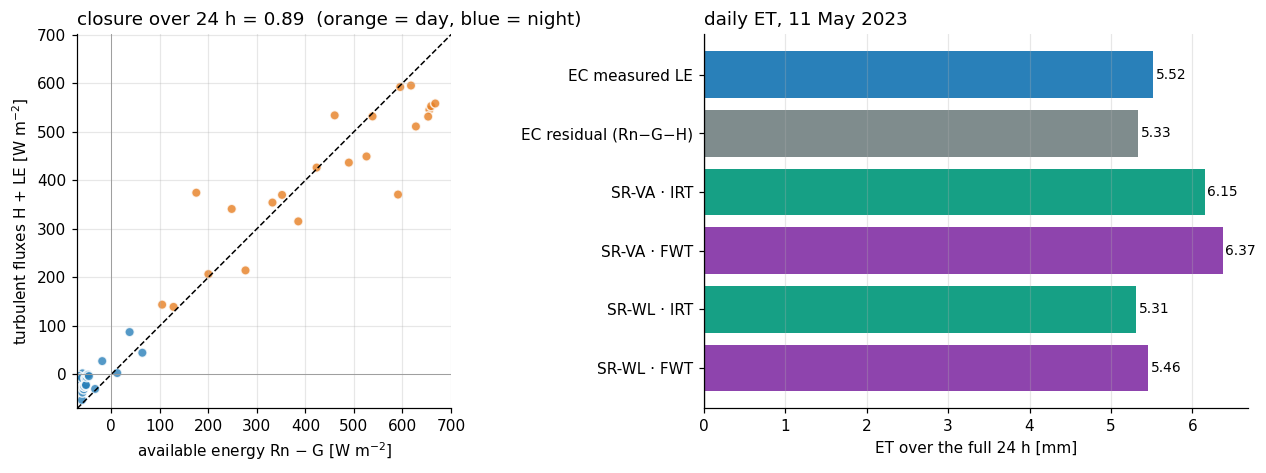

In [13]:
LAMBDA = 2.45e6
full = d.dropna(subset=["NETRAD", "G", "H", "LE"])          # all 48 blocks

et = {}
for meth, col in combos:
    le = latent_heat_residual(full.NETRAD.to_numpy(), full.G.to_numpy(),
                              full[f"H_{meth}_{col}"].to_numpy())
    et[f"SR-{meth} · {col}"] = daily_et(le, block_s=BLOCK_S)
et["EC residual (Rn−G−H)"] = daily_et(
    latent_heat_residual(full.NETRAD.to_numpy(), full.G.to_numpy(), full.H.to_numpy()),
    block_s=BLOCK_S)
et["EC measured LE"] = daily_et(full.LE.to_numpy(), block_s=BLOCK_S)

fig, (axa, axb) = plt.subplots(1, 2, figsize=(12, 4.4))

avail = (full.NETRAD - full.G).to_numpy()
turb = (full.H + full.LE).to_numpy()
lim = [min(avail.min(), turb.min()) * 1.05, max(avail.max(), turb.max()) * 1.05]
axa.scatter(avail, turb, s=38, c=np.where(full.NETRAD > 50, "#e67e22", "#2980b9"),
            alpha=0.8, edgecolors="white")
axa.plot(lim, lim, "k--", lw=1)
axa.axhline(0, color="#999", lw=0.6); axa.axvline(0, color="#999", lw=0.6)
sl = np.sum(avail * turb) / np.sum(avail ** 2)
axa.set(xlim=lim, ylim=lim, aspect="equal",
        xlabel="available energy Rn − G [W m$^{-2}$]",
        ylabel="turbulent fluxes H + LE [W m$^{-2}$]")
axa.set_title(f"closure over 24 h = {sl:.2f}  (orange = day, blue = night)", loc="left")

names = list(et)
axb.barh(names, [et[k] for k in names],
         color=["#8e44ad", "#16a085", "#8e44ad", "#16a085", "#7f8c8d", "#2980b9"])
axb.axvline(0, color="#333", lw=0.8)
axb.set_xlabel("ET over the full 24 h [mm]")
axb.set_title("daily ET, 11 May 2023", loc="left")
for i, k in enumerate(names):
    axb.text(et[k] + 0.03, i, f"{et[k]:.2f}", va="center", fontsize=9)
axb.grid(axis="y", alpha=0)
plt.tight_layout()

pd.Series(et).round(2).to_frame("ET [mm]")

The measured-LE bar sits below the residual bars because this tower, like most, does not
close its energy balance — the residual method assigns the missing energy to LE. That gap
is a property of the site, not of surface renewal, and it is why calibrating against a
closure-corrected H is preferable when one is available.

## Takeaways

1. **The whole chain runs out-of-sample** on a traditional, non-advective day: α came from
   the other 30 days of July 2023, and no coefficient was fitted on the day being scored.
2. **The regime split earns its place.** The nocturnal coefficient is roughly half the
   daytime one at this site, so a single all-day α would over-estimate the weak night flux.
   How much smaller is site- and season-specific — in an advective month the two came out
   nearly equal.
3. **No flux-direction convention survived every day tested.** Skin-ramp skewness is right in
   92 % of daytime blocks here and air-ramp skewness in 8 %; on days from 2025 and 2026 that
   ranking reverses. The surface-air gradient never works once the housing thermistor's 2023
   bias is removed. Validate the convention you intend to use against a reference, over a
   range of conditions, and again after any instrument change.
4. Compare `α·z`, not α, whenever the length-scale convention differs — only the product is
   identifiable from data.
5. **The applied detector configuration must match the calibrated one.** The SR-VA lag and
   period mode are read from the calibration file rather than set here; an earlier version of
   this notebook applied coefficients fitted with one configuration to fluxes computed with
   another, and the α ratio came out ~50× wrong.